# Run this first !
Ensures correct libraries and imports data

In [1]:

# Run this first !
# project setup — run first, do not edit except NAME
NAME = "rachel" # <<< your name

import sys, subprocess, pathlib
IN_COLAB = "google.colab" in sys.modules
REPO = "boe-financial-analysis"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    if not pathlib.Path(f"/content/{REPO}").exists():
        subprocess.run(["git", "clone", "-q",
                        f"https://github.com/maybebool/{REPO}.git",
                        f"/content/{REPO}"], check=True)
    ROOT = pathlib.Path(f"/content/{REPO}")
    DATA = pathlib.Path("/content/drive/MyDrive/boe-data")
else:
    ROOT = pathlib.Path.cwd()
    while not (ROOT / "requirements.txt").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    DATA = ROOT / "data"

sys.path.insert(0, str(ROOT))
subprocess.run(["git", "-C", str(ROOT), "fetch", "-q", "origin"], check=False)
subprocess.run(["git", "-C", str(ROOT), "merge", "-q", "origin/main", "-m", "sync"],
               check=False)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                str(ROOT / "requirements.txt")], check=True)

from notebooks.env_cell import verify, check_python
check_python()
try:
    verify(ROOT)
except RuntimeError as e:
    print(e)
    print("\n Runtime -> Restart session, then run this cell again.")
    raise

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from src import loading

print(f"ok  python {sys.version.split()[0]}  pandas {pd.__version__}  data {DATA}")
print(loading.exports(DATA))
print(loading.files(DATA))

utt = loading.load(DATA, "all_utterances.csv", "2026-09-13")
sent = loading.load(DATA, "all_sentences.csv", "2026-09-13")
met = loading.load(DATA, "all_metrics.csv", "2026-09-13")

print(utt.shape, sent.shape, met.shape)
sent.head()
data=sent.copy()

ok  python 3.12.13  pandas 2.2.3  data /Users/rdrobinson/Cambridge/boe-financial-analysis/data
['2026-09-13']
['all_metrics.csv', 'all_sentences.csv', 'all_utterances.csv']
loaded all_utterances.csv  1201 rows
loaded all_sentences.csv  9519 rows
loaded all_metrics.csv  510 rows
(1201, 11) (9519, 12) (510, 6)


In [2]:
print(loading.exports(DATA))
print(loading.files(DATA))

utt = loading.load(DATA, "all_utterances.csv", "2026-09-13")
sent = loading.load(DATA, "all_sentences.csv", "2026-09-13")
met = loading.load(DATA, "all_metrics.csv", "2026-09-13")

print(utt.shape, sent.shape, met.shape)
sent.head()

['2026-09-13']
['all_metrics.csv', 'all_sentences.csv', 'all_utterances.csv']
loaded all_utterances.csv  1201 rows
loaded all_sentences.csv  9519 rows
loaded all_metrics.csv  510 rows
(1201, 11) (9519, 12) (510, 6)


,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence
0,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,9789,1,"Good morning, ladies and gentlemen."
1,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,9790,2,Welcome to JPMorgan Chase’s First Quarter 2023...
2,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,9791,3,This call is being recorded.
3,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,9792,4,Your line will be muted for the duration of th...
4,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,9793,5,We will now go live to the presentation.


In [3]:
data=sent.copy()

# Sentence pre-processing (stop words etc)
This is just a starting point as there are several oddities - for example greeting words mean the Bert Emotion skews towards "Joy" and some stopwords such as "us" seems to be treated as a plural of "u" - hence needs removing. Also need to work out how to differentiate between "credit" and "Credit Suisse" as both are valid but cannot be treated as the same

In [4]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [5]:
def preprocess_text(text):
    if not isinstance(text, str): # Handle non-string input, e.g., NaN
        return []
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize the text
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    stop_words = set(stopwords.words('english'))

    # Remove words that are not informative for topic modeling
    stop_words.update(['also', 'quarter', 'year', 'u', 'think', 'thats'])

    greeting_words = {
    "hello", "hi", "dear", "greetings",
    "thank", "thanks", "good", "morning",
    "afternoon", "evening",
    "ladies", "gentlemen", "sir", "madam",
    "yeah", "welcome"
}

    lemmatizer = WordNetLemmatizer()
    cleaned_tokens = [
        lemmatizer.lemmatize(word) for word in tokens
        if word not in stop_words and word.isalpha() and word not in greeting_words # Ensure only alphabetic words are kept and remove greeting words
    ]
    return [word for word in cleaned_tokens if word not in stop_words]

In [6]:
# Apply the preprocessing function
data['cleaned_text'] = data['sentence'].apply(preprocess_text)

# Display the first few rows
print(data[['sentence', 'cleaned_text']].head())

                                            sentence  \
0                Good morning, ladies and gentlemen.   
1  Welcome to JPMorgan Chase’s First Quarter 2023...   
2                       This call is being recorded.   
3  Your line will be muted for the duration of th...   
4           We will now go live to the presentation.   

                               cleaned_text  
0                                        []  
1  [jpmorgan, chase, first, earnings, call]  
2                          [call, recorded]  
3             [line, muted, duration, call]  
4                  [go, live, presentation]  


# UBS Data

In [7]:
# Create dataframe with bank = ubs
ubs_data = data[data['bank'] == 'UBS'].copy()
print(ubs_data.shape)
ubs_data.head(2)

(4714, 13)


,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence,cleaned_text
4805,UBS,2023-Q1,earnings,2023-04-25,1,prepared,management,Sergio P. Ermotti,NaN,5075,1,"Thank you, Sarah, good morning, everyone.","[sarah, everyone]"
4806,UBS,2023-Q1,earnings,2023-04-25,1,prepared,management,Sergio P. Ermotti,NaN,5076,2,I am happy to be back here with all of you.,"[happy, back]"


Now need to split this further into prepared (from the presentation) and q&a

In [8]:
# Create ubs dataframe with section = 'prepared'
ubs_prepared_data = ubs_data[ubs_data['section'] == 'prepared'].copy()
print(ubs_prepared_data.shape)
ubs_prepared_data.head(2)


(2061, 13)


,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence,cleaned_text
4805,UBS,2023-Q1,earnings,2023-04-25,1,prepared,management,Sergio P. Ermotti,NaN,5075,1,"Thank you, Sarah, good morning, everyone.","[sarah, everyone]"
4806,UBS,2023-Q1,earnings,2023-04-25,1,prepared,management,Sergio P. Ermotti,NaN,5076,2,I am happy to be back here with all of you.,"[happy, back]"


In [10]:
# Count different numbers of speakers in UBS prepared section
ubs_prepared_speaker_counts = ubs_prepared_data['speaker_name'].value_counts()
print(ubs_prepared_speaker_counts)

speaker_name
Todd Tuckner         1221
Sergio P. Ermotti     752
Sarah Youngwood        88
Name: count, dtype: int64


In [11]:
# Create ubs dataframe with section = 'q&a'
ubs_qa_data = ubs_data[ubs_data['section'] == 'qa'].copy()
print(ubs_qa_data.shape)
ubs_qa_data.head(2)

(2653, 13)


,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence,cleaned_text
4983,UBS,2023-Q1,earnings,2023-04-25,3,qa,analyst,Chris Hallam,Goldman Sachs,5253,1,Yes.,[yes]
4984,UBS,2023-Q1,earnings,2023-04-25,3,qa,analyst,Chris Hallam,Goldman Sachs,5254,2,"Good morning, everybody.",[everybody]


In [12]:
# Count different numbers of speakers in UBS q&a section
ubs_qa_speaker_counts = ubs_qa_data['speaker_name'].value_counts()
print(ubs_qa_speaker_counts)

speaker_name
Todd Tuckner         807
Sergio P. Ermotti    628
Andrew Coombs        128
Jeremy Sigee         112
Kian Abouhossein     102
Chris Hallam          90
Giulia Miotto         83
Amit Goel             79
Benjamin Goy          76
Anke Reingen          74
Stefan Stalmann       69
Adam Terelak          61
Sarah Youngwood       61
Andrew Lim            60
Alastair Ryan         48
Piers Brown           45
Tom Hallett           40
Flora Bocahut         36
Nicolas Payen         21
Antonio Reale         17
Vishal Shah           11
Sarah Mackey           5
Name: count, dtype: int64


## Bert Emotion: UBS Presentation section

In [13]:
# Conduct Bert Emotion analysis on cleaned sentences from presentation section (UBS)
from transformers import pipeline
emotion_analyzer = pipeline("text-classification", model="bhadresh-savani/bert-base-uncased-emotion")
documents = (
    ubs_prepared_data["cleaned_text"]
    .apply(lambda tokens: " ".join(tokens) if isinstance(tokens, list) else str(tokens))
    .tolist()
 )
basic_emotion = emotion_analyzer(documents, truncation=True)

print("Sentence emotion analysis:")
print(basic_emotion)

# Add emotion and score to the dataframe
ubs_prepared_data["emotion"] = [item["label"] for item in basic_emotion]
ubs_prepared_data["score"] = [item["score"] for item in basic_emotion]
ubs_prepared_data.head(2)

/Users/rdrobinson/Cambridge/boe-financial-analysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7822.51it/s]


Sentence emotion analysis:
[{'label': 'anger', 'score': 0.7325093746185303}, {'label': 'joy', 'score': 0.995882511138916}, {'label': 'joy', 'score': 0.9909369349479675}, {'label': 'joy', 'score': 0.874218761920929}, {'label': 'joy', 'score': 0.9964756369590759}, {'label': 'joy', 'score': 0.7256629467010498}, {'label': 'joy', 'score': 0.9959501028060913}, {'label': 'anger', 'score': 0.944121778011322}, {'label': 'joy', 'score': 0.9956008195877075}, {'label': 'joy', 'score': 0.7882832884788513}, {'label': 'joy', 'score': 0.9466054439544678}, {'label': 'joy', 'score': 0.9725730419158936}, {'label': 'joy', 'score': 0.9945249557495117}, {'label': 'joy', 'score': 0.9914754629135132}, {'label': 'joy', 'score': 0.9820072054862976}, {'label': 'anger', 'score': 0.6292346119880676}, {'label': 'joy', 'score': 0.9380383491516113}, {'label': 'joy', 'score': 0.9949723482131958}, {'label': 'joy', 'score': 0.9880453944206238}, {'label': 'joy', 'score': 0.9004260897636414}, {'label': 'joy', 'score': 0.9

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence,cleaned_text,emotion,score
4805,UBS,2023-Q1,earnings,2023-04-25,1,prepared,management,Sergio P. Ermotti,NaN,5075,1,"Thank you, Sarah, good morning, everyone.","[sarah, everyone]",anger,0.732509
4806,UBS,2023-Q1,earnings,2023-04-25,1,prepared,management,Sergio P. Ermotti,NaN,5076,2,I am happy to be back here with all of you.,"[happy, back]",joy,0.995883


In [14]:
# Create dataframe to calculate mean and standard deviation of every emotion every quarter (UBS)
ubs_prepared_emotion_stats = ubs_prepared_data.groupby(["quarter", "emotion"]).agg(
    mean_score=("score", "mean"),
    std_score=("score", "std")
).reset_index()
ubs_prepared_emotion_stats.head(10)

,quarter,emotion,mean_score,std_score
0,2023-Q1,anger,0.709658,0.177017
1,2023-Q1,fear,0.826759,0.228856
2,2023-Q1,joy,0.911762,0.134927
3,2023-Q1,sadness,0.584894,0.118052
4,2023-Q2,anger,0.685924,0.165123
5,2023-Q2,fear,0.720541,0.145921
6,2023-Q2,joy,0.904250,0.146774
7,2023-Q2,sadness,0.614878,0.182249
8,2023-Q2,surprise,0.987155,NaN
9,2023-Q3,anger,0.657675,0.144955


In [15]:
# Set colours
##emotion_colors = {
#    "joy": "yellow",
#    "sadness": "blue",
#    "anger": "red",
#    "fear": "purple",
#    "surprise": "green",
#    "disgust": "brown",
#    "love": "pink"
#}

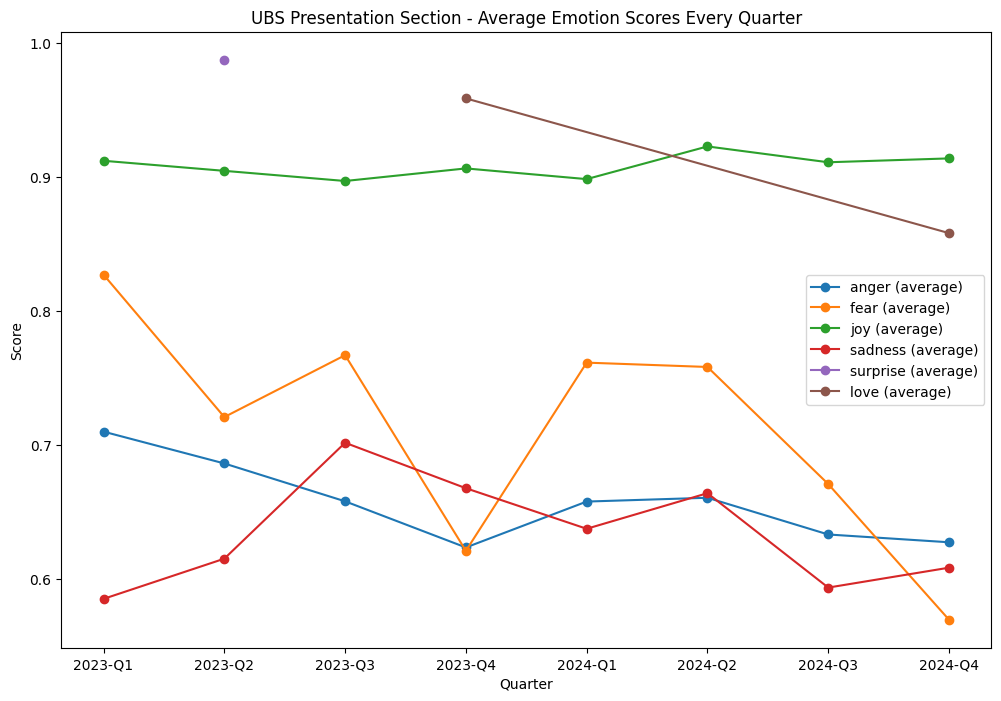

In [16]:
# Plot mean and standard deviation of every emotion every quarter as a scatter plot on the same plot (UBS)
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
for emotion in ubs_prepared_emotion_stats["emotion"].unique():
    emotion_prepared_data = ubs_prepared_emotion_stats[ubs_prepared_emotion_stats["emotion"] == emotion]
    # Add lines
    # use pre-defined colours for emotions
    #color = emotion_colors.get(emotion, "black")
    plt.plot(emotion_prepared_data["quarter"], emotion_prepared_data["mean_score"], label=f"{emotion} (average)", marker='o')
    # Add error bars for standard deviation
    #plt.errorbar(emotion_prepared_data["quarter"], emotion_prepared_data["mean_score"], yerr=emotion_prepared_data["std_score"], fmt='o', alpha=0.5)
plt.title("UBS Presentation Section - Average Emotion Scores Every Quarter")
plt.xlabel("Quarter")
plt.ylabel("Score")
plt.legend()
plt.show()



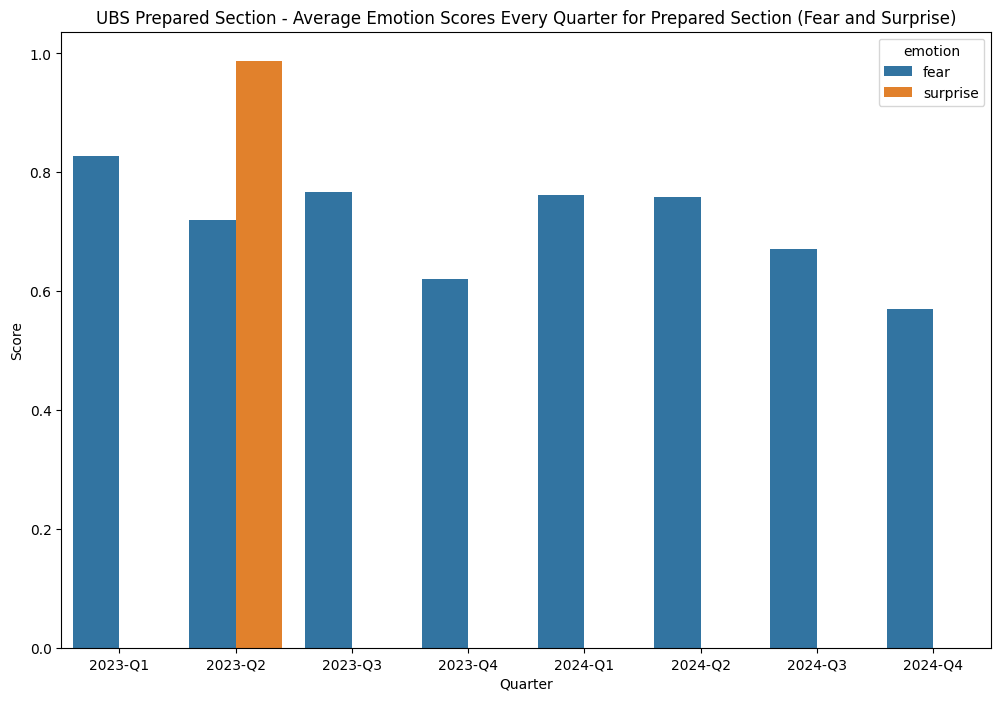

In [17]:
# Plot emotions fear and surprise only as grouped barchart (UBS)
import seaborn as sns
plt.figure(figsize=(12, 8))
fear_surprise_prepared_data = ubs_prepared_emotion_stats[ubs_prepared_emotion_stats["emotion"].isin(["fear", "surprise"])]
sns.barplot(data=fear_surprise_prepared_data, x="quarter", y="mean_score", hue="emotion")
plt.title("UBS Prepared Section - Average Emotion Scores Every Quarter for Prepared Section (Fear and Surprise)")
plt.xlabel("Quarter")
plt.ylabel("Score")
plt.show()

## Bert Emotion: UBS Q&A section

In [18]:
# Conduct Bert Emotion analysis on cleaned sentences from Q&Asection (UBS)
from transformers import pipeline
emotion_analyzer = pipeline("text-classification", model="bhadresh-savani/bert-base-uncased-emotion")
documents = (
    ubs_qa_data["cleaned_text"]
    .apply(lambda tokens: " ".join(tokens) if isinstance(tokens, list) else str(tokens))
    .tolist()
 )
basic_emotion = emotion_analyzer(documents, truncation=True)

print("Sentence emotion analysis:")
print(basic_emotion)

# Add emotion and score to the dataframe
ubs_qa_data["emotion"] = [item["label"] for item in basic_emotion]
ubs_qa_data["score"] = [item["score"] for item in basic_emotion]
ubs_qa_data.head(2)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 8312.68it/s]


Sentence emotion analysis:
[{'label': 'joy', 'score': 0.9654083847999573}, {'label': 'joy', 'score': 0.6069585680961609}, {'label': 'joy', 'score': 0.6349568963050842}, {'label': 'anger', 'score': 0.6373898983001709}, {'label': 'joy', 'score': 0.6702774167060852}, {'label': 'anger', 'score': 0.9562810063362122}, {'label': 'joy', 'score': 0.7324752807617188}, {'label': 'joy', 'score': 0.7465758323669434}, {'label': 'joy', 'score': 0.9931960105895996}, {'label': 'joy', 'score': 0.9740347266197205}, {'label': 'anger', 'score': 0.29154786467552185}, {'label': 'joy', 'score': 0.9564871788024902}, {'label': 'joy', 'score': 0.800778329372406}, {'label': 'anger', 'score': 0.9022621512413025}, {'label': 'joy', 'score': 0.9845656752586365}, {'label': 'joy', 'score': 0.9964227080345154}, {'label': 'joy', 'score': 0.9407902359962463}, {'label': 'joy', 'score': 0.9810662269592285}, {'label': 'joy', 'score': 0.8140438795089722}, {'label': 'joy', 'score': 0.9787343740463257}, {'label': 'anger', 'scor

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence,cleaned_text,emotion,score
4983,UBS,2023-Q1,earnings,2023-04-25,3,qa,analyst,Chris Hallam,Goldman Sachs,5253,1,Yes.,[yes],joy,0.965408
4984,UBS,2023-Q1,earnings,2023-04-25,3,qa,analyst,Chris Hallam,Goldman Sachs,5254,2,"Good morning, everybody.",[everybody],joy,0.606959


In [19]:
# Create dataframe to calculate mean and standard deviation of every emotion every quarter (UBS)
ubs_qa_emotion_stats = ubs_qa_data.groupby(["quarter", "emotion"]).agg(
    mean_score=("score", "mean"),
    std_score=("score", "std")
).reset_index()
ubs_qa_emotion_stats.head(10)

,quarter,emotion,mean_score,std_score
0,2023-Q1,anger,0.582797,0.260981
1,2023-Q1,fear,0.702503,0.209412
2,2023-Q1,joy,0.888393,0.146285
3,2023-Q1,love,0.870791,NaN
4,2023-Q1,sadness,0.734288,0.196733
5,2023-Q1,surprise,0.721857,0.281027
6,2023-Q2,anger,0.609720,0.250953
7,2023-Q2,fear,0.741069,0.302594
8,2023-Q2,joy,0.887764,0.146273
9,2023-Q2,sadness,0.682321,0.174092


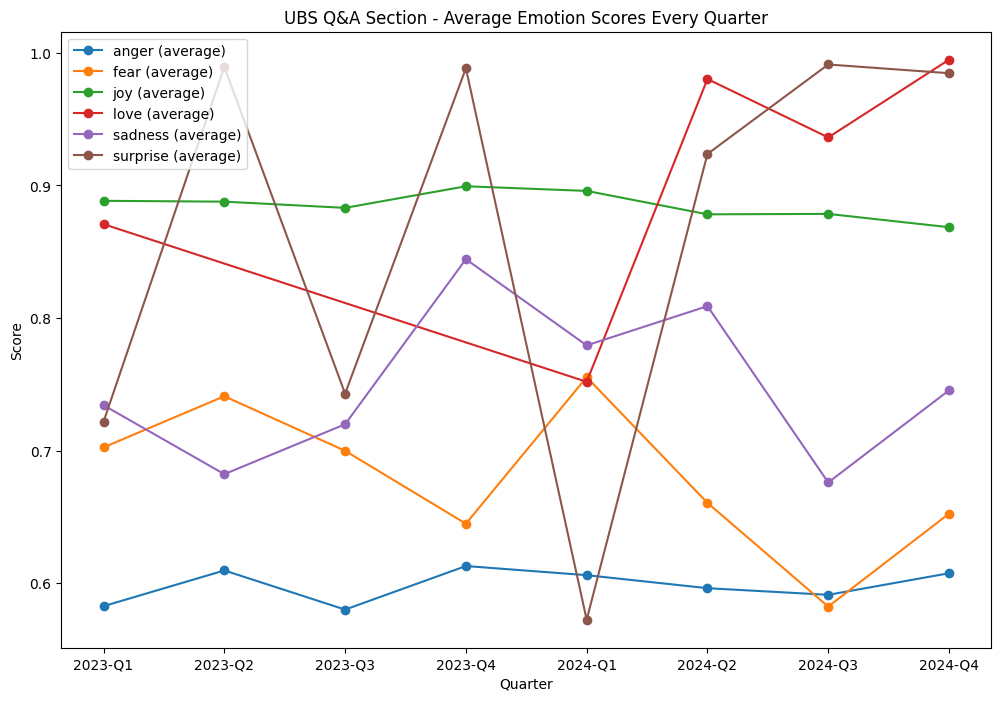

In [20]:
# Plot mean and standard deviation of every emotion every quarter as a scatter plot on the same plot (UBS)
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
for emotion in ubs_qa_emotion_stats["emotion"].unique():
    emotion_qa_data = ubs_qa_emotion_stats[ubs_qa_emotion_stats["emotion"] == emotion]
    # Add lines
    # use pre-defined colours for emotions
    #color = emotion_colors.get(emotion, "black")
    plt.plot(emotion_qa_data["quarter"], emotion_qa_data["mean_score"], label=f"{emotion} (average)", marker='o')
plt.title("UBS Q&A Section - Average Emotion Scores Every Quarter")
plt.xlabel("Quarter")
plt.ylabel("Score")
plt.legend()
plt.show()

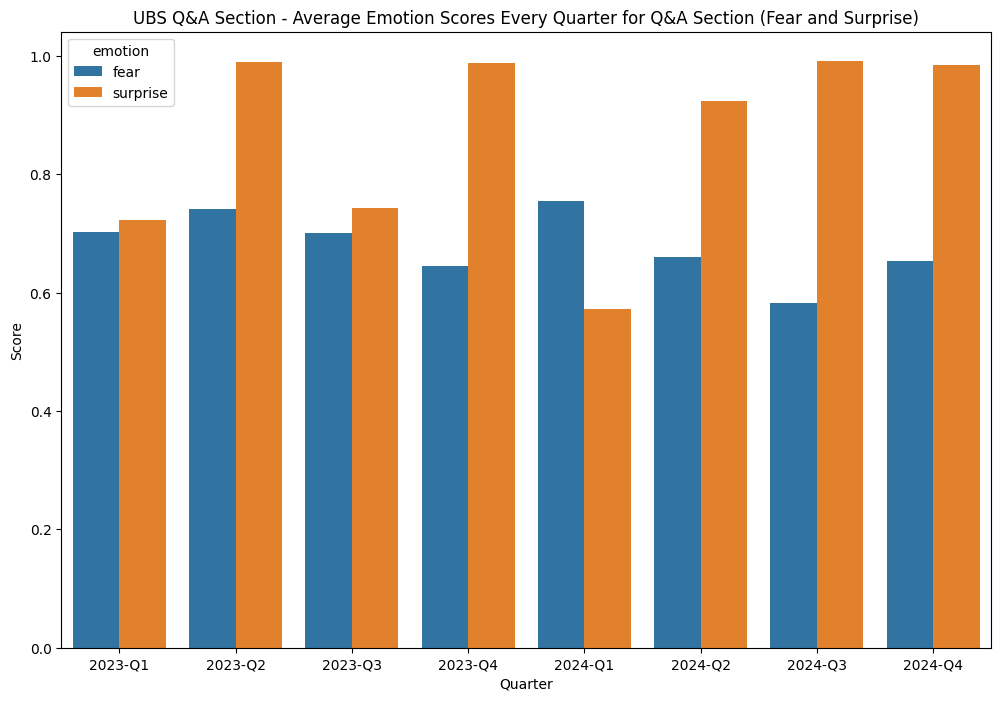

In [21]:
# Plot emotions fear and surprise only as grouped barchart (UBS)
import seaborn as sns
plt.figure(figsize=(12, 8))
fear_surprise_qa_data = ubs_qa_emotion_stats[ubs_qa_emotion_stats["emotion"].isin(["fear", "surprise"])]
sns.barplot(data=fear_surprise_qa_data, x="quarter", y="mean_score", hue="emotion")
plt.title("UBS Q&A Section - Average Emotion Scores Every Quarter for Q&A Section (Fear and Surprise)")
plt.xlabel("Quarter")
plt.ylabel("Score")
plt.show()

## Main Presenters (UBS)
Create a subset with just the main speakers from the presentation section

In [51]:
# Filter UBS qa data to just include speaker_name = Todd Tuckner and Sergio P. Ermotti
ubs_qa_filtered = ubs_qa_data[(ubs_qa_data['speaker_name'] == 'Todd Tuckner') | (ubs_qa_data['speaker_name'] == 'Sergio P. Ermotti')]
ubs_qa_filtered.head(2)


,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence,cleaned_text,emotion,score
4992,UBS,2023-Q1,earnings,2023-04-25,4,qa,management,Sergio P. Ermotti,NaN,5262,1,Okay.,[okay],joy,0.974035
4993,UBS,2023-Q1,earnings,2023-04-25,4,qa,management,Sergio P. Ermotti,NaN,5263,2,Thank you.,[],anger,0.291548


In [52]:
# Create dataframe to calculate mean and standard deviation of every emotion every quarter (UBS)
ubs_qa_filtered_emotion_stats = ubs_qa_filtered.groupby(["quarter", "emotion"]).agg(
    mean_score=("score", "mean"),
    std_score=("score", "std")
).reset_index()
ubs_qa_filtered_emotion_stats.head(10)

,quarter,emotion,mean_score,std_score
0,2023-Q1,anger,0.609078,0.239041
1,2023-Q1,fear,0.742048,0.240042
2,2023-Q1,joy,0.905277,0.142553
3,2023-Q1,sadness,0.758330,0.240039
4,2023-Q2,anger,0.598894,0.211856
5,2023-Q2,fear,0.766913,0.365154
6,2023-Q2,joy,0.890445,0.146572
7,2023-Q2,sadness,0.703453,0.182372
8,2023-Q3,anger,0.679677,0.226466
9,2023-Q3,fear,0.631322,0.151424


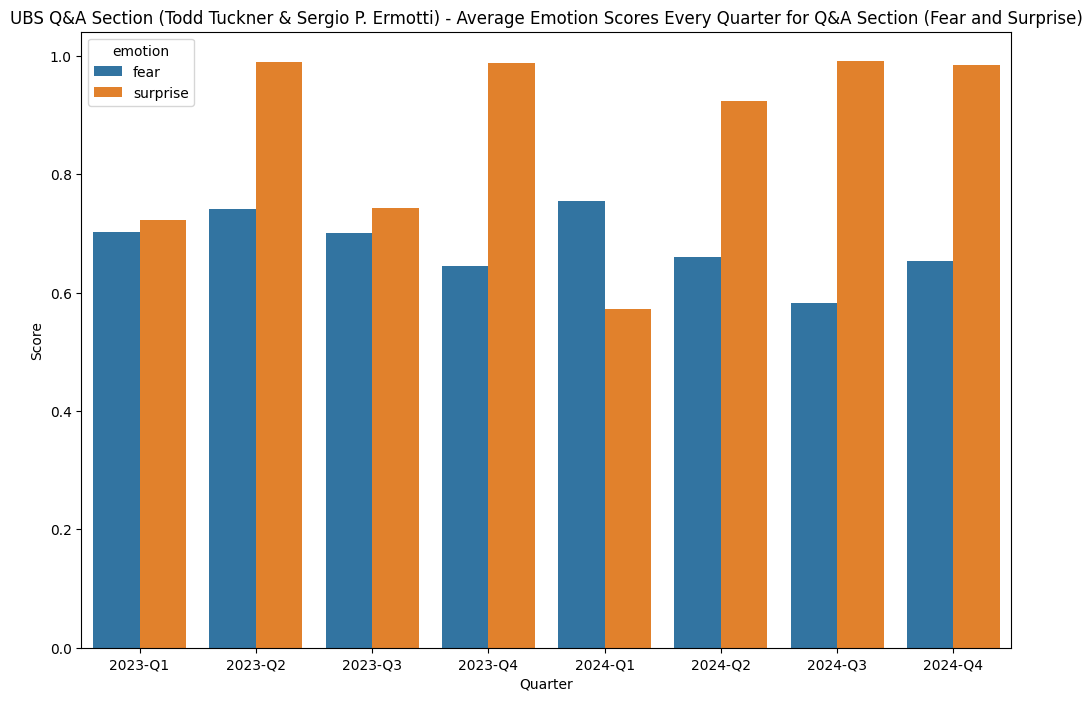

In [53]:
# Plot emotions fear and surprise only as grouped barchart (UBS)
import seaborn as sns
plt.figure(figsize=(12, 8))
ubs_fear_surprise_qa_filtered_data = ubs_qa_emotion_stats[ubs_qa_emotion_stats["emotion"].isin(["fear", "surprise"])]
sns.barplot(data=ubs_fear_surprise_qa_filtered_data, x="quarter", y="mean_score", hue="emotion")
plt.title("UBS Q&A Section (Todd Tuckner & Sergio P. Ermotti) - Average Emotion Scores Every Quarter for Q&A Section (Fear and Surprise)")
plt.xlabel("Quarter")
plt.ylabel("Score")
plt.show()

# JPM Data

In [22]:
# Create dataframe with bank = jpm
jpm_data = data[data['bank'] == 'JPM'].copy()
print(jpm_data.shape)
jpm_data.head(2)

(4805, 13)


,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence,cleaned_text
0,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,9789,1,"Good morning, ladies and gentlemen.",[]
1,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,9790,2,Welcome to JPMorgan Chase’s First Quarter 2023...,"[jpmorgan, chase, first, earnings, call]"


In [23]:
# Create jpm dataframe with section = 'prepared'
jpm_prepared_data = jpm_data[jpm_data['section'] == 'prepared'].copy()
print(jpm_prepared_data.shape)
jpm_prepared_data.head(2)

(942, 13)


,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence,cleaned_text
0,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,9789,1,"Good morning, ladies and gentlemen.",[]
1,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,9790,2,Welcome to JPMorgan Chase’s First Quarter 2023...,"[jpmorgan, chase, first, earnings, call]"


In [24]:
# Count different numbers of speakers in JPM prepared section
jpm_prepared_speaker_counts = jpm_prepared_data['speaker_name'].value_counts()
print(jpm_prepared_speaker_counts)

speaker_name
Jeremy Barnum    855
Operator          77
Jamie Dimon       10
Name: count, dtype: int64


In [25]:
# Create jpm dataframe with section = 'q&a'
jpm_qa_data = jpm_data[jpm_data['section'] == 'qa'].copy()
print(jpm_qa_data.shape)
jpm_qa_data.head(2)

(3863, 13)


,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence,cleaned_text
112,JPM,2023-Q1,earnings,2023-04-14,3,qa,operator,Operator,NaN,9901,1,Please stand by.,"[please, stand]"
113,JPM,2023-Q1,earnings,2023-04-14,3,qa,operator,Operator,NaN,9902,2,The first question is coming from the line of ...,"[first, question, coming, line, steve, chubak,..."


In [26]:
# Count different numbers of speakers in JPM q&a section
jpm_qa_speaker_counts = jpm_qa_data['speaker_name'].value_counts()
print(jpm_qa_speaker_counts)


speaker_name
Jeremy Barnum           1673
Jamie Dimon              688
Operator                 268
Mike Mayo                150
Betsy L. Graseck         146
Gerard Cassidy           125
Erika Najarian           107
Ebrahim H. Poonawala     100
Glenn Schorr              97
Matt O'Connor             97
Jim Mitchell              95
Steven Chubak             79
John McDonald             69
Ken Usdin                 52
Charles W. Peabody        43
Saul Martinez             36
Ryan Kenny                14
Scott Siefers             13
Manan Gosalia             11
Name: count, dtype: int64


## Bert Emotion: JPM Presentation section

In [ ]:
# Conduct Bert Emotion analysis on cleaned sentences from presentation section (JPM)
from transformers import pipeline
emotion_analyzer = pipeline("text-classification", model="bhadresh-savani/bert-base-uncased-emotion")
documents = (
    jpm_prepared_data["cleaned_text"]
    .apply(lambda tokens: " ".join(tokens) if isinstance(tokens, list) else str(tokens))
    .tolist()
 )
basic_emotion = emotion_analyzer(documents, truncation=True)

print("Sentence emotion analysis:")
print(basic_emotion)

# Add emotion and score to the dataframe
jpm_prepared_data["emotion"] = [item["label"] for item in basic_emotion]
jpm_prepared_data["score"] = [item["score"] for item in basic_emotion]
jpm_prepared_data.head(2)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7058.10it/s]


Sentence emotion analysis:
[{'label': 'anger', 'score': 0.29154786467552185}, {'label': 'joy', 'score': 0.5934081673622131}, {'label': 'anger', 'score': 0.5362944006919861}, {'label': 'anger', 'score': 0.6360952854156494}, {'label': 'joy', 'score': 0.9826142191886902}, {'label': 'joy', 'score': 0.9436234831809998}, {'label': 'joy', 'score': 0.781797468662262}, {'label': 'joy', 'score': 0.958483874797821}, {'label': 'anger', 'score': 0.7296066880226135}, {'label': 'anger', 'score': 0.59098881483078}, {'label': 'joy', 'score': 0.9911655783653259}, {'label': 'anger', 'score': 0.3588503301143646}, {'label': 'sadness', 'score': 0.9164242148399353}, {'label': 'joy', 'score': 0.9773510694503784}, {'label': 'joy', 'score': 0.9935163259506226}, {'label': 'joy', 'score': 0.32183411717414856}, {'label': 'joy', 'score': 0.9511504769325256}, {'label': 'joy', 'score': 0.9754054546356201}, {'label': 'joy', 'score': 0.8080428242683411}, {'label': 'anger', 'score': 0.6347299218177795}, {'label': 'joy',

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence,cleaned_text,emotion,score
0,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,9789,1,"Good morning, ladies and gentlemen.",[],anger,0.291548
1,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,9790,2,Welcome to JPMorgan Chase’s First Quarter 2023...,"[jpmorgan, chase, first, earnings, call]",joy,0.593408


In [30]:
# Create dataframe to calculate mean and standard deviation of every emotion every quarter (UBS)
jpm_prepared_emotion_stats = jpm_prepared_data.groupby(["quarter", "emotion"]).agg(
    mean_score=("score", "mean"),
    std_score=("score", "std")
).reset_index()
jpm_prepared_emotion_stats.head(10)

,quarter,emotion,mean_score,std_score
0,2023-Q1,anger,0.589692,0.143847
1,2023-Q1,fear,0.813608,0.187824
2,2023-Q1,joy,0.846480,0.173062
3,2023-Q1,sadness,0.561844,0.189120
4,2023-Q2,anger,0.668337,0.168922
5,2023-Q2,fear,0.665175,0.228872
6,2023-Q2,joy,0.865693,0.161962
7,2023-Q2,sadness,0.845327,0.100764
8,2023-Q3,anger,0.640304,0.180555
9,2023-Q3,fear,0.675287,0.169562


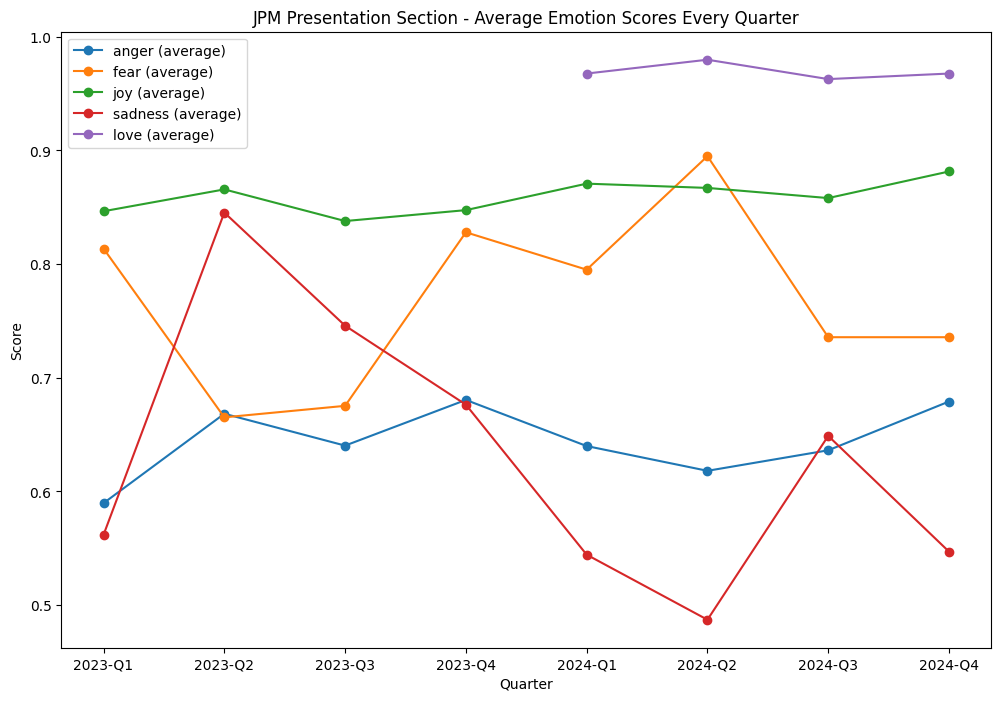

In [31]:
# Plot mean and standard deviation of every emotion every quarter as a scatter plot on the same plot (JPM)
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
for emotion in jpm_prepared_emotion_stats["emotion"].unique():
    jpm_emotion_prepared_data = jpm_prepared_emotion_stats[jpm_prepared_emotion_stats["emotion"] == emotion]
    # Add lines
    # use pre-defined colours for emotions
    #color = emotion_colors.get(emotion, "black")
    plt.plot(jpm_emotion_prepared_data["quarter"], jpm_emotion_prepared_data["mean_score"], label=f"{emotion} (average)", marker='o')
    # Add error bars for standard deviation
    #plt.errorbar(jpm_emotion_prepared_data["quarter"], jpm_emotion_prepared_data["mean_score"], yerr=jpm_emotion_prepared_data["std_score"], fmt='o', alpha=0.5)
plt.title("JPM Presentation Section - Average Emotion Scores Every Quarter")
plt.xlabel("Quarter")
plt.ylabel("Score")
plt.legend()
plt.show()

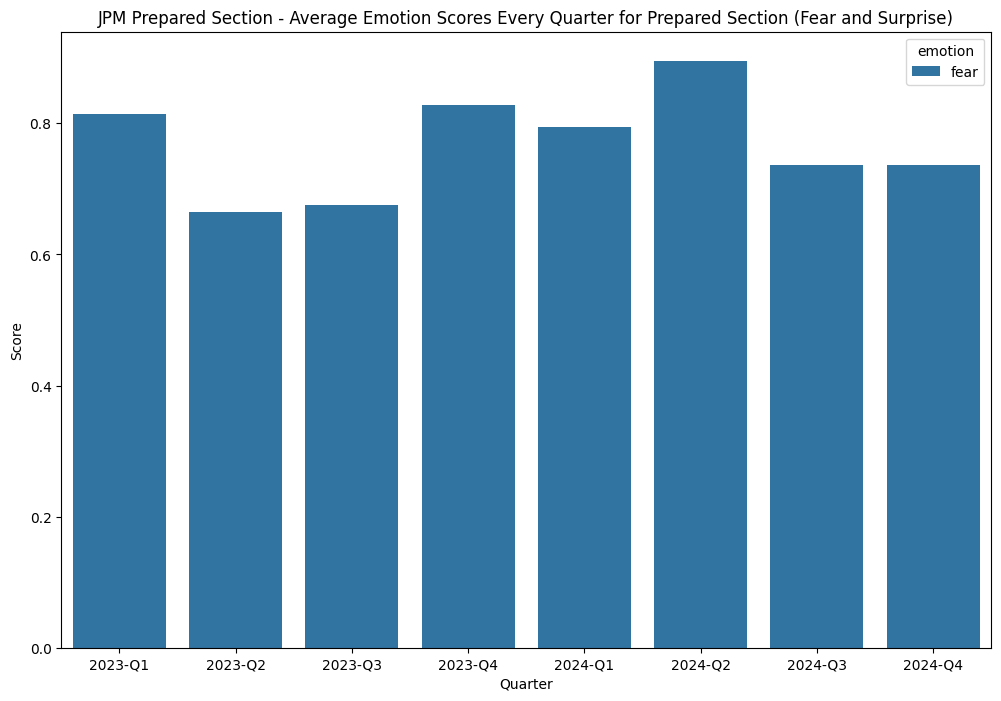

In [32]:
# Plot emotions fear and surprise only as grouped barchart (JPM)
import seaborn as sns
plt.figure(figsize=(12, 8))
fear_surprise_prepared_data = jpm_prepared_emotion_stats[jpm_prepared_emotion_stats["emotion"].isin(["fear", "surprise"])]
sns.barplot(data=fear_surprise_prepared_data, x="quarter", y="mean_score", hue="emotion")
plt.title("JPM Prepared Section - Average Emotion Scores Every Quarter for Prepared Section (Fear and Surprise)")
plt.xlabel("Quarter")
plt.ylabel("Score")
plt.show()

## Bert Emotion: JPM Q&A section

In [33]:
# Conduct Bert Emotion analysis on cleaned sentences from Q&Asection (JPM)
from transformers import pipeline
emotion_analyzer = pipeline("text-classification", model="bhadresh-savani/bert-base-uncased-emotion")
documents = (
    jpm_qa_data["cleaned_text"]
    .apply(lambda tokens: " ".join(tokens) if isinstance(tokens, list) else str(tokens))
    .tolist()
 )
basic_emotion = emotion_analyzer(documents, truncation=True)

print("Sentence emotion analysis:")
print(basic_emotion)

# Add emotion and score to the dataframe
jpm_qa_data["emotion"] = [item["label"] for item in basic_emotion]
jpm_qa_data["score"] = [item["score"] for item in basic_emotion]
jpm_qa_data.head(2)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 6865.72it/s]


Sentence emotion analysis:
[{'label': 'joy', 'score': 0.9436234831809998}, {'label': 'joy', 'score': 0.9607129096984863}, {'label': 'joy', 'score': 0.9677883982658386}, {'label': 'anger', 'score': 0.7048393487930298}, {'label': 'joy', 'score': 0.9610016345977783}, {'label': 'anger', 'score': 0.46958833932876587}, {'label': 'joy', 'score': 0.8487571477890015}, {'label': 'joy', 'score': 0.620550811290741}, {'label': 'joy', 'score': 0.9817012548446655}, {'label': 'joy', 'score': 0.9946038126945496}, {'label': 'joy', 'score': 0.8688619136810303}, {'label': 'anger', 'score': 0.5702351331710815}, {'label': 'joy', 'score': 0.7547147870063782}, {'label': 'joy', 'score': 0.977011501789093}, {'label': 'joy', 'score': 0.9954276084899902}, {'label': 'anger', 'score': 0.8315522074699402}, {'label': 'anger', 'score': 0.29154786467552185}, {'label': 'joy', 'score': 0.8849195241928101}, {'label': 'joy', 'score': 0.8292891979217529}, {'label': 'joy', 'score': 0.5318835377693176}, {'label': 'joy', 'scor

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence,cleaned_text,emotion,score
112,JPM,2023-Q1,earnings,2023-04-14,3,qa,operator,Operator,NaN,9901,1,Please stand by.,"[please, stand]",joy,0.943623
113,JPM,2023-Q1,earnings,2023-04-14,3,qa,operator,Operator,NaN,9902,2,The first question is coming from the line of ...,"[first, question, coming, line, steve, chubak,...",joy,0.960713


In [35]:
# Create dataframe to calculate mean and standard deviation of every emotion every quarter (UBS)
jpm_qa_emotion_stats = jpm_qa_data.groupby(["quarter", "emotion"]).agg(
    mean_score=("score", "mean"),
    std_score=("score", "std")
).reset_index()
jpm_qa_emotion_stats.head(10)

,quarter,emotion,mean_score,std_score
0,2023-Q1,anger,0.621060,0.246932
1,2023-Q1,fear,0.745284,0.207021
2,2023-Q1,joy,0.850946,0.159693
3,2023-Q1,love,0.834918,0.118935
4,2023-Q1,sadness,0.745051,0.195228
5,2023-Q1,surprise,0.987181,NaN
6,2023-Q2,anger,0.601043,0.264003
7,2023-Q2,fear,0.637089,0.200593
8,2023-Q2,joy,0.873800,0.157114
9,2023-Q2,love,0.704893,0.302096


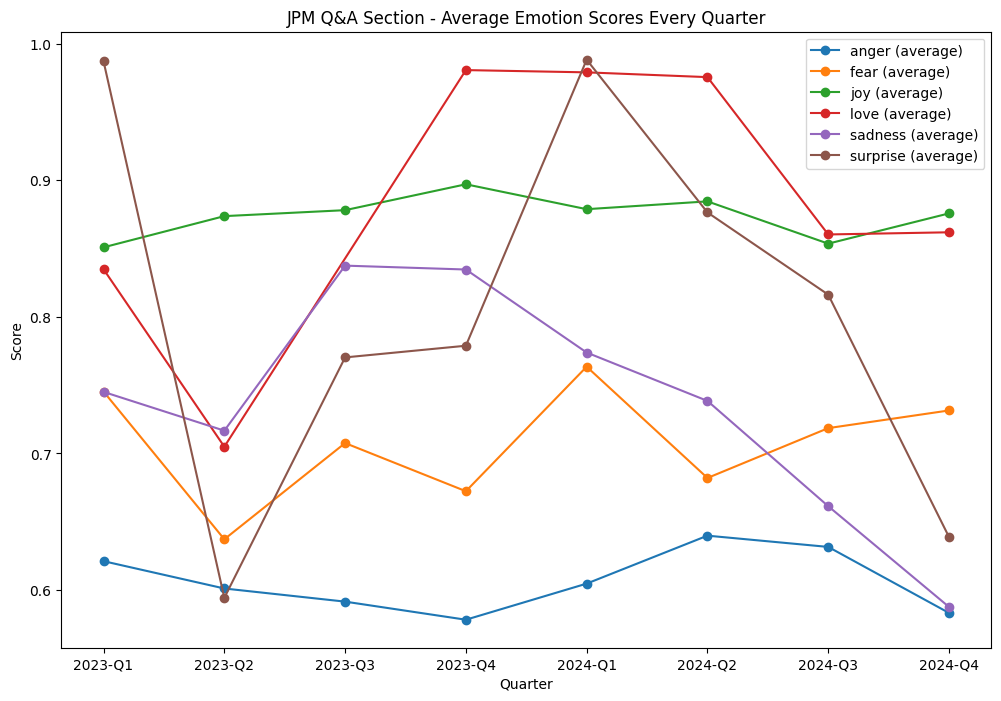

In [36]:
# Plot mean and standard deviation of every emotion every quarter as a scatter plot on the same plot (JPM)
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
for emotion in jpm_qa_emotion_stats["emotion"].unique():
    jpm_emotion_qa_data = jpm_qa_emotion_stats[jpm_qa_emotion_stats["emotion"] == emotion]
    # Add lines
    # use pre-defined colours for emotions
    #color = emotion_colors.get(emotion, "black")
    plt.plot(jpm_emotion_qa_data["quarter"], jpm_emotion_qa_data["mean_score"], label=f"{emotion} (average)", marker='o')
plt.title("JPM Q&A Section - Average Emotion Scores Every Quarter")
plt.xlabel("Quarter")
plt.ylabel("Score")
plt.legend()
plt.show()

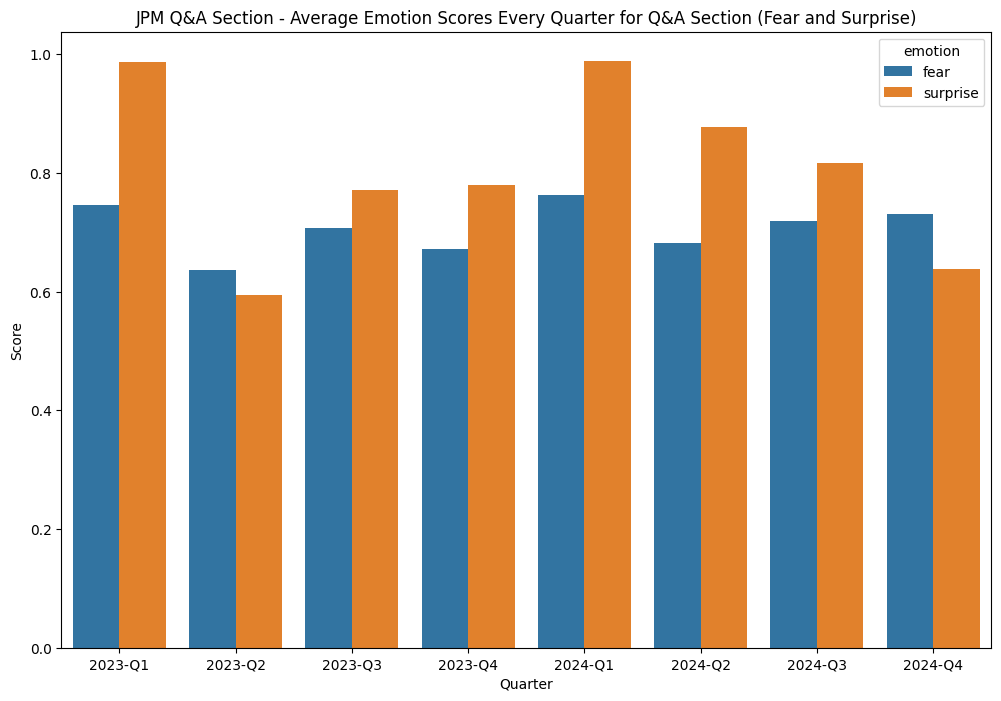

In [37]:
# Plot emotions fear and surprise only as grouped barchart (JPM)
import seaborn as sns
plt.figure(figsize=(12, 8))
fear_surprise_qa_data = jpm_qa_emotion_stats[jpm_qa_emotion_stats["emotion"].isin(["fear", "surprise"])]
sns.barplot(data=fear_surprise_qa_data, x="quarter", y="mean_score", hue="emotion")
plt.title("JPM Q&A Section - Average Emotion Scores Every Quarter for Q&A Section (Fear and Surprise)")
plt.xlabel("Quarter")
plt.ylabel("Score")
plt.show()

## Main Presenters (JPM)
Create a subset with just the main speakers from the presentation section

In [54]:
# Filter JPM qa data to just include speaker_name = Jeremy Barnum and Jamie Dimon
jpm_qa_filtered = jpm_qa_data[(jpm_qa_data['speaker_name'] == 'Jeremy Barnum') | (jpm_qa_data['speaker_name'] == 'Jamie Dimon')]
jpm_qa_filtered.head(2)


,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence,cleaned_text,emotion,score
115,JPM,2023-Q1,earnings,2023-04-14,5,qa,management,Jeremy Barnum,NaN,9904,1,"Good morning, Steve.",[steve],anger,0.704839
120,JPM,2023-Q1,earnings,2023-04-14,7,qa,management,Jamie Dimon,NaN,9909,1,"Well, I think you were already kind of complet...","[well, already, kind, complete, answering, que...",joy,0.981701


In [55]:
# Create dataframe to calculate mean and standard deviation of every emotion every quarter (UBS)
jpm_qa_filtered_emotion_stats = jpm_qa_filtered.groupby(["quarter", "emotion"]).agg(
    mean_score=("score", "mean"),
    std_score=("score", "std")
).reset_index()
jpm_qa_filtered_emotion_stats.head(10)

,quarter,emotion,mean_score,std_score
0,2023-Q1,anger,0.637534,0.230239
1,2023-Q1,fear,0.731347,0.221405
2,2023-Q1,joy,0.846136,0.169025
3,2023-Q1,love,0.919017,NaN
4,2023-Q1,sadness,0.765858,0.201061
5,2023-Q2,anger,0.633516,0.251619
6,2023-Q2,fear,0.550350,0.167587
7,2023-Q2,joy,0.876524,0.160329
8,2023-Q2,love,0.965790,0.038028
9,2023-Q2,sadness,0.682457,0.223099


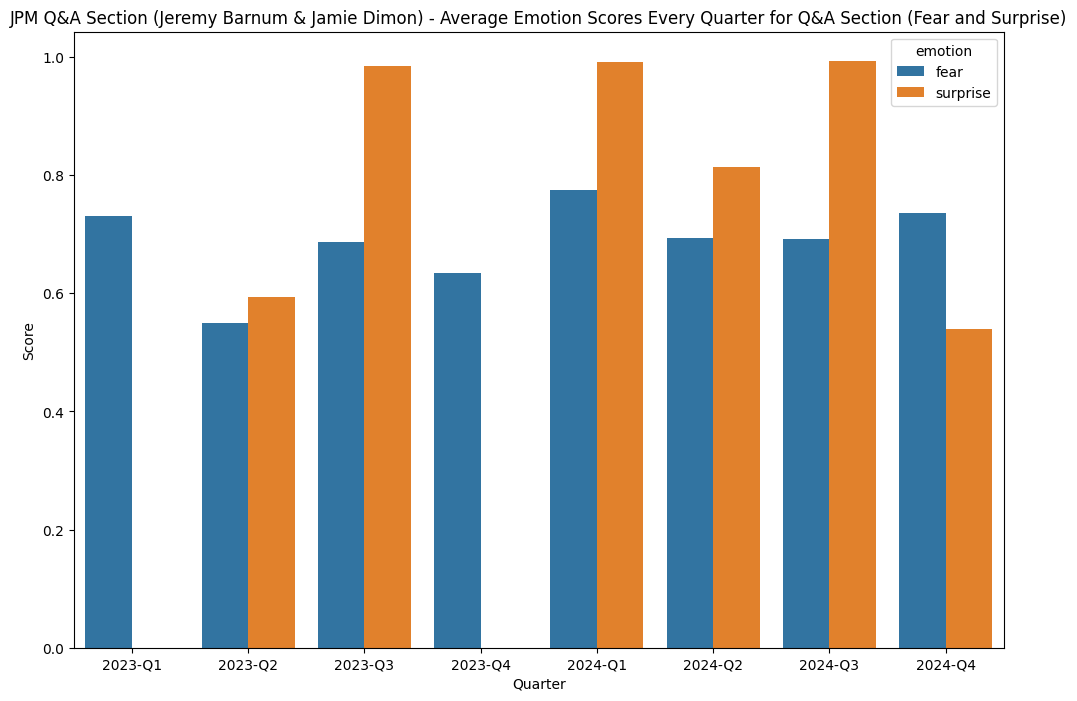

In [56]:
# Plot emotions fear and surprise only as grouped barchart (UBS)
import seaborn as sns
plt.figure(figsize=(12, 8))
jpm_fear_surprise_qa_filtered_data = jpm_qa_filtered_emotion_stats[jpm_qa_filtered_emotion_stats["emotion"].isin(["fear", "surprise"])]
sns.barplot(data=jpm_fear_surprise_qa_filtered_data, x="quarter", y="mean_score", hue="emotion")
plt.title("JPM Q&A Section (Jeremy Barnum & Jamie Dimon) - Average Emotion Scores Every Quarter for Q&A Section (Fear and Surprise)")
plt.xlabel("Quarter")
plt.ylabel("Score")
plt.show()